# Create virtual environment
- Install a Virtual Environment using Venv  
    `pip install virtualenv`  
- Create Virtual Environment  
    `python -m venv pyenv`  
    `ls`  
- Activate  
    - Linux: `source pyenv/bin/activate`  
    - Windows: 
        `pyenv/Scripts/Activate.ps1` 
        `<pyenv/Scripts/activate`  
- List python libraries  
    `pip list`  
- Create Requirements.txt (You can name this requirements.txt file whatever you want.)  
    `pip freeze > requirements.txt`  
- Install from requirements.txt  
    `pip install -r requirements.txt`  
- Deactivate  
    `deactivate`

## Jupyter Labs
Install JupyterLab with pip

`pip install jupyterlab`


**Fixed-Size Chunking** using LangChain's `CharacterTextSplitter`:
✅ Splits the text into **1000-character chunks**  
✅ Preserves word boundaries (avoids cutting words mid-way)  
✅ Helps in **text embeddings & retrieval**  

In [ ]:
def load_text_from_file(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        return file.read()
    
document_text = load_text_from_file("sampleText.txt")

In [ ]:
from langchain_text_splitters import CharacterTextSplitter

text_splitter = CharacterTextSplitter(chunk_size =1000, chunk_overlap=0,separator="")

chunks=text_splitter.split_text(document_text)

In [13]:
for i, chunk in enumerate(chunks):
    print(f"🔹 Chunk {i+1} (Size: {len(chunk)} characters):\n{chunk}\n{'-'*50}\n")


🔹 Chunk 1 (Size: 1000 characters):
Types of Technology
1. Information Technology
IT is a broad field that encompasses digital data management, storage, and retrieval. IT professionals work with computer systems, networks, software, and databases to ensure data integrity and accessibility. IT is pivotal in various industries, facilitating efficient data management and decision-making.

Hardware: Computers, servers, laptops, smartphones, and other devices.
Software: Operating systems, applications, and programming languages.
Networking: Routers, switches, and protocols for data communication.
Cybersecurity: Tools and techniques to protect digital assets from threats.
2. Communication Technology
Communication technology comprises the tools and systems used to transmit and receive information. This includes telecommunication networks, mobile devices, and internet protocols. The rapid evolution of communication technology has revolutionized global connectivity, making it easier than ever fo

# 🔄 Overlapping (Sliding Window) Chunking

In **fixed-size chunking**, text is split into equal-sized chunks, but important context may be lost at boundaries.  
**Overlapping Chunking (Sliding Window)** solves this by allowing chunks to overlap.

### **✅ Why Use Overlapping Chunking?**
- **Preserves context** across chunks 🧠  
- **Improves retrieval performance** for LLMs 🔍  
- **Useful for semantic search & embeddings**  

### **📌 How This Works**
- `chunk_size=1000` → Each chunk is **1000 characters long**  
- `chunk_overlap=50` → Each chunk **shares 50 characters** with the next  



In [24]:
text_splitter = CharacterTextSplitter(chunk_size = 1000, chunk_overlap=100, separator="")
overlapping_chunks=text_splitter.split_text(document_text)


In [26]:
for i, chunk in enumerate(overlapping_chunks):
    print(f"🔹 Chunk {i+1} (Size: {len(chunk)} characters):\n{chunk}\n{'-'*50}\n")


🔹 Chunk 1 (Size: 1000 characters):
Types of Technology
1. Information Technology
IT is a broad field that encompasses digital data management, storage, and retrieval. IT professionals work with computer systems, networks, software, and databases to ensure data integrity and accessibility. IT is pivotal in various industries, facilitating efficient data management and decision-making.

Hardware: Computers, servers, laptops, smartphones, and other devices.
Software: Operating systems, applications, and programming languages.
Networking: Routers, switches, and protocols for data communication.
Cybersecurity: Tools and techniques to protect digital assets from threats.
2. Communication Technology
Communication technology comprises the tools and systems used to transmit and receive information. This includes telecommunication networks, mobile devices, and internet protocols. The rapid evolution of communication technology has revolutionized global connectivity, making it easier than ever fo

# Recursive Character Text Splitting

The problem with Character Text Splitting is that we don't take into account the structure of our document at all. We simply split by a fix number of characters.

The Recursive Character Text Splitter helps with this. With it, we'll specify a series of separatators which will be used to split our docs.

### **🛠 Default Separators**
Here are the default separators used by LangChain's Recursive Character Text Splitter:

1. **`"\n\n"`** – Double newline, commonly used to indicate **paragraph breaks**.  
2. **`"\n"`** – Single newline, useful for breaking at **lines or sentences**.  
3. **`" "`** – Space, used to separate words or phrases.  
4. **`""`** – Finally, if the chunk is still too large, it will break by individual **characters**.

### ✅ **Why Use Recursive Character Text Splitting?**
- **Respects document structure**: Splits based on logical units (paragraphs, sentences) 🧠  
- **Versatile separators**: Uses a hierarchy of separators to ensure chunks make sense  
- **Helps in real-world scenarios**: Perfect for documents with complex layouts  

### 🔄 **How It Works**
- First, it looks for **paragraph breaks** (`"\n\n"`).
- If the chunk is still too large, it splits by **new lines** (`"\n"`), then **spaces** (`" "`), and finally by individual **characters** (`""`).
- The goal is to split at **natural boundaries**, without cutting off important information.


In [28]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap=0)

chunks= text_splitter.split_text(document_text)

In [29]:
for i, chunk in enumerate(chunks):
    print(f"🔹 **Chunk {i+1}** (Size: {len(chunk)} characters):\n{chunk}\n{'-'*50}\n")

🔹 **Chunk 1** (Size: 351 characters):
Types of Technology
1. Information Technology
IT is a broad field that encompasses digital data management, storage, and retrieval. IT professionals work with computer systems, networks, software, and databases to ensure data integrity and accessibility. IT is pivotal in various industries, facilitating efficient data management and decision-making.
--------------------------------------------------

🔹 **Chunk 2** (Size: 680 characters):
Hardware: Computers, servers, laptops, smartphones, and other devices.
Software: Operating systems, applications, and programming languages.
Networking: Routers, switches, and protocols for data communication.
Cybersecurity: Tools and techniques to protect digital assets from threats.
2. Communication Technology
Communication technology comprises the tools and systems used to transmit and receive information. This includes telecommunication networks, mobile devices, and internet protocols. The rapid evolution of co

Notice that after applying the Recursive Character Text Splitter:
- Chunks will **end** with a period (".") when possible, as it's likely the end of a sentence or paragraph.
- You'll see **more chunks** compared to fixed-size splitting, as the text respects its structure.

# Document-Specific Splitting

Standard text-based splitting methods work well for simple `.txt` files, but **real-world data** comes in many formats:
- 🖼 **PDFs** (with images and multi-column layouts)  
- 📝 **Markdown files** (with headings, code blocks, and lists)  
- 🖥 **Programming files** (`Python`, `JavaScript`, etc.)  

For these **structured documents**, a **tailored chunking approach** is needed to maintain readability and logical separation.

---

## 🛠 **Specialized Splitting for Different Document Types**
LangChain provides **document-aware splitters** that go beyond basic text splitting.

### **📑 Markdown Splitting**
Markdown (`.md`) files have **structured elements** like headers, lists, and code blocks. To split them correctly, we use a **custom separator strategy**:

**Separators for Markdown:**

\n#{1,6} - Split by new lines followed by a header (H1 through H6)
```\n - Code blocks
\n\\*\\*\\*+\n - Horizontal Lines
\n---+\n - Horizontal Lines
\n___+\n - Horizontal Lines
\n\n Double new lines
\n - New line
" " - Spaces
"" - Character

In [30]:
with open("sampleText.md", "r", encoding="utf-8") as file:
    markdown_content = file.read()


In [33]:
from langchain.text_splitter import MarkdownTextSplitter

splitter = MarkdownTextSplitter(chunk_size = 1000, chunk_overlap=0)
chunks = splitter.split_text(markdown_content)

In [34]:
for i, chunk in enumerate(chunks):
    print(f"🔹 **Chunk {i+1}** (Size: {len(chunk)} characters):\n{chunk}\n{'-'*50}\n")

🔹 **Chunk 1** (Size: 942 characters):
**Types of Technology and Their Impact**

Technology is a driving force behind societal progress, influencing every aspect of our lives. Understanding the various types of technology is essential for navigating the modern world and harnessing its potential. Here's a breakdown of key technology categories:

**1. Information Technology (IT)**

* **Description:** IT focuses on the management and processing of digital information. It includes hardware, software, networking, and cybersecurity.
* **Components:**
    * Hardware: Computers, servers, mobile devices.
    * Software: Operating systems, applications, databases.
    * Networking: Internet, local area networks (LANs), wide area networks (WANs).
    * Cybersecurity: Firewalls, antivirus software, intrusion detection systems.
* **Impact:** IT facilitates efficient data management, communication, and decision-making across industries.

**2. Communication Technology (CommsTech)**
-------------------

**Notice how the splits gravitate towards markdown sections.**

**Separators for Python**

\nclass - Classes first
\ndef - Functions next
\n\tdef - Indented functions
\n\n - Double New lines
\n - New Lines
" " - Spaces
"" - Characters

In [41]:
def load_text_from_file(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        return file.read()
    
python_text = load_text_from_file("samplePythonText.txt")

In [42]:
from langchain.text_splitter import PythonCodeTextSplitter

python_splitter = PythonCodeTextSplitter(chunk_size=1000, chunk_overlap=0)
chunks= python_splitter.split_text(python_text)

In [43]:
for i, chunk in enumerate(chunks):
    print(f"🔹 **Chunk {i+1}** (Size: {len(chunk)} characters):\n{chunk}\n{'-'*50}\n")

🔹 **Chunk 1** (Size: 25 characters):
import random
import time
--------------------------------------------------

🔹 **Chunk 2** (Size: 770 characters):
class Point:
    """Represents a point in 2D space."""

    def __init__(self, x, y):
        """Initializes a Point object."""
        self.x = x
        self.y = y

    def __repr__(self):
        """Returns a string representation of the Point."""
        return f"({self.x:.2f}, {self.y:.2f})"

def generate_random_points(num_points=100):
    """Generates a list of Point objects with random coordinates."""
    points = []
    for _ in range(num_points):
        x = random.uniform(0, 100)
        y = random.uniform(0, 100)
        points.append(Point(x, y))
    return points

def calculate_distance(point1, point2):
    """Calculates the Euclidean distance between two Point objects."""
    return ((point2.x - point1.x) ** 2 + (point2.y - point1.y) ** 2) ** 0.5
--------------------------------------------------

🔹 **Chunk 3** (Size: 689

# Semantic Chunking 

## The Problem with Traditional Chunking
Traditional chunking techniques like **fixed-size chunking** or **sentence-based chunking** don't consider the semantic meaning of the text. They break the content into chunks purely based on size, sentence breaks, or other delimiters. But content-based chunks should be grouped based on their **meaning** rather than arbitrary limits. 

## Semantic Chunking with Embeddings
Embeddings represent the semantic meaning of a string. While embeddings don't do much on their own, by comparing the embeddings of different texts, we can infer relationships between chunks. The hypothesis is that **semantically similar chunks should be held together**.

### Find Break Points Between Sequential Sentences

For this method, we use a **sliding window** approach on sentences to find "break points" between semantically related chunks. Here's the approach:

1. **Starting at the first sentence**, we calculate its embedding.
2. **Compare each subsequent sentence** to the previous one by checking the similarity of their embeddings.
3. If the **distance between embeddings** is above a certain threshold, we consider that a **break point** — meaning we now have two separate semantic chunks.
4. Instead of comparing embeddings of each individual sentence (which can be noisy), we take **groups of 3 consecutive sentences** as a "window" to calculate embeddings. 
   - Once the embedding for a window of 3 sentences is calculated, we **drop the first sentence** and add the next sentence in the sequence.
   - This helps smooth out short sentences and minimizes noise.

In [62]:
with open('sampleText.txt') as file:
    document = file.read()

In [ ]:
import re
# Splitting the essay on '.', '?', and '!'
single_sentences_list = re.split(r'(?<=[.?!])\s+', document)
print (f"{len(single_sentences_list)} senteneces were found")

155 senteneces were found


In [65]:
sentences = [{'sentence': x, 'index' : i} for i, x in enumerate(single_sentences_list)]
sentences[:3]

[{'sentence': 'Types of Technology\n1.', 'index': 0},
 {'sentence': 'Information Technology\nIT is a broad field that encompasses digital data management, storage, and retrieval.',
  'index': 1},
 {'sentence': 'IT professionals work with computer systems, networks, software, and databases to ensure data integrity and accessibility.',
  'index': 2}]

Great, now that we have our sentences, we need to combine the sentence before and after so that we reduce noise and capture more of the relationships between sequential sentences.

Let's create a function so we can use it again. The buffer_size is configurable so you can select how big of a window you want.

In [68]:
def combine_sentences(sentences, buffer_size=1):
   
    for i in range(len(sentences)):
        combined_sentence = ''
        for j in range(i - buffer_size, i):
            if j >= 0:
                combined_sentence += sentences[j]['sentence'] + ' '

        combined_sentence += sentences[i]['sentence']

        for j in range(i + 1, i + 1 + buffer_size):
            if j < len(sentences):
                combined_sentence += ' ' + sentences[j]['sentence']

        sentences[i]['combined_sentence'] = combined_sentence

    return sentences

sentences = combine_sentences(sentences)
sentences[:3]

[{'sentence': 'Types of Technology\n1.',
  'index': 0,
  'combined_sentence': 'Types of Technology\n1. Information Technology\nIT is a broad field that encompasses digital data management, storage, and retrieval.'},
 {'sentence': 'Information Technology\nIT is a broad field that encompasses digital data management, storage, and retrieval.',
  'index': 1,
  'combined_sentence': 'Types of Technology\n1. Information Technology\nIT is a broad field that encompasses digital data management, storage, and retrieval. IT professionals work with computer systems, networks, software, and databases to ensure data integrity and accessibility.'},
 {'sentence': 'IT professionals work with computer systems, networks, software, and databases to ensure data integrity and accessibility.',
  'index': 2,
  'combined_sentence': 'Information Technology\nIT is a broad field that encompasses digital data management, storage, and retrieval. IT professionals work with computer systems, networks, software, and da

Now We need to get embeddings for the combined sentences, so we can get the distances between the groups of 3 and find breakpoints.

In [89]:
from langchain_openai import AzureOpenAIEmbeddings

api_key = "4ixSZu8G7iUAXGkchETA8pm7KjvaMwJVX3IWUYdpg35eetFZoOorJQQJ99BCACYeBjFXJ3w3AAABACOGBzhO"
endpoint = "https://aisession-openaiservice.openai.azure.com"

oaiembeds = AzureOpenAIEmbeddings(
    azure_deployment="text-embedding-ada-002",
    azure_endpoint=endpoint,
    openai_api_version="2023-05-15"
)


In [90]:
embeddings = oaiembeds.embed_documents([x['combined_sentence'] for x in sentences])

In [93]:
for i, sentence in enumerate(sentences):
    sentence['combined_sentence_embedding'] = embeddings[i]

 let's check out the cosine distances between sequential embedding pairs to see where the break points are. We'll add 'distance_to_next' as another key

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def calculate_cosine_distances(sentences):
    distances = []
    for i in range(len(sentences) - 1):
        embedding_current = sentences[i]['combined_sentence_embedding']
        embedding_next = sentences[i + 1]['combined_sentence_embedding']
        
        # Calculate cosine similarity
        similarity = cosine_similarity([embedding_current], [embedding_next])[0][0]
        
        # Convert to cosine distance
        distance = 1 - similarity

        # Append cosine distance to the list
        distances.append(distance)

        # Store distance in the dictionary
        sentences[i]['distance_to_next'] = distance

    return distances, sentences

In [94]:
distances, sentences = calculate_cosine_distances(sentences)

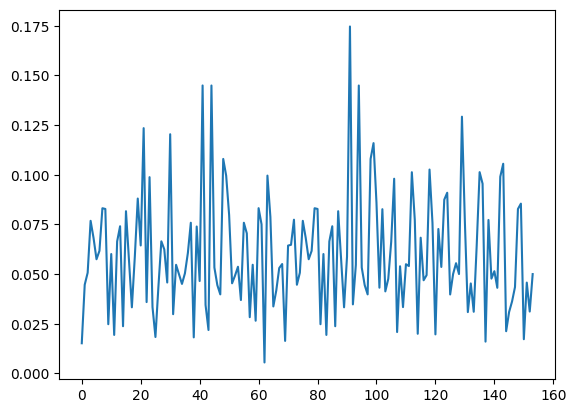

In [95]:
import matplotlib.pyplot as plt

plt.plot(distances)

There are many ways to chunk up the text based off these distances, but we are going to consider any distance above the 95th percentile of distances as a break point.

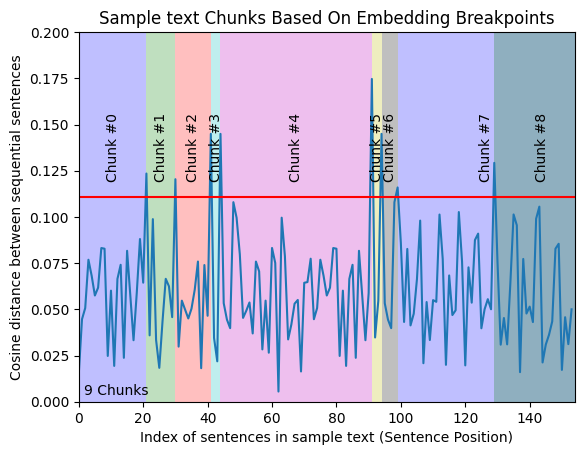

In [103]:
import numpy as np

plt.plot(distances)

y_upper_bound = .2
plt.ylim(0, y_upper_bound)
plt.xlim(0, len(distances))

# We need to get the distance threshold that we'll consider an outlier
# We'll use numpy .percentile() for this
breakpoint_percentile_threshold = 95
breakpoint_distance_threshold = np.percentile(distances, breakpoint_percentile_threshold) # If you want more chunks, lower the percentile cutoff
plt.axhline(y=breakpoint_distance_threshold, color='r', linestyle='-')

# Then we'll see how many distances are actually above this one
num_distances_above_theshold = len([x for x in distances if x > breakpoint_distance_threshold]) # The amount of distances above your threshold
plt.text(x=(len(distances)*.01), y=y_upper_bound/50, s=f"{num_distances_above_theshold + 1} Chunks")

# Then we'll get the index of the distances that are above the threshold. This will tell us where we should split our text
indices_above_thresh = [i for i, x in enumerate(distances) if x > breakpoint_distance_threshold] # The indices of those breakpoints on your list

# Start of the shading and text
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
for i, breakpoint_index in enumerate(indices_above_thresh):
    start_index = 0 if i == 0 else indices_above_thresh[i - 1]
    end_index = breakpoint_index if i < len(indices_above_thresh) - 1 else len(distances)

    plt.axvspan(start_index, end_index, facecolor=colors[i % len(colors)], alpha=0.25)
    plt.text(x=np.average([start_index, end_index]),
             y=breakpoint_distance_threshold + (y_upper_bound)/ 20,
             s=f"Chunk #{i}", horizontalalignment='center',
             rotation='vertical')

# # Additional step to shade from the last breakpoint to the end of the dataset
if indices_above_thresh:
    last_breakpoint = indices_above_thresh[-1]
    if last_breakpoint < len(distances):
        plt.axvspan(last_breakpoint, len(distances), facecolor=colors[len(indices_above_thresh) % len(colors)], alpha=0.25)
        plt.text(x=np.average([last_breakpoint, len(distances)]),
                 y=breakpoint_distance_threshold + (y_upper_bound)/ 20,
                 s=f"Chunk #{i+1}",
                 rotation='vertical')

plt.title("Sample text Chunks Based On Embedding Breakpoints")
plt.xlabel("Index of sentences in sample text (Sentence Position)")
plt.ylabel("Cosine distance between sequential sentences")
plt.show()

Now we need to combine the sentences into chunks.
Because we have our breakpoints [23, 40, 51...], we need to make the first chunk 0-22, since the distance jumped on sentence 23.

In [100]:
# Initialize the start index
start_index = 0

# Create a list to hold the grouped sentences
semantic_chunks = []

# Iterate through the breakpoints to slice the sentences
for index in indices_above_thresh:
    # The end index is the current breakpoint
    end_index = index

    # Slice the sentence_dicts from the current start index to the end index
    group = sentences[start_index:end_index + 1]
    combined_text = ' '.join([d['sentence'] for d in group])
    semantic_chunks.append(combined_text)
    
    # Update the start index for the next group
    start_index = index + 1

# The last group, if any sentences remain
if start_index < len(sentences):
    combined_text = ' '.join([d['sentence'] for d in sentences[start_index:]])
    semantic_chunks.append(combined_text)


In [101]:
for i, chunk in enumerate(semantic_chunks):
    print(f"🔹 **Chunk {i+1}** (Size: {len(chunk)} characters):\n{chunk}\n{'-'*50}\n")

🔹 **Chunk 1** (Size: 1854 characters):
Types of Technology
1. Information Technology
IT is a broad field that encompasses digital data management, storage, and retrieval. IT professionals work with computer systems, networks, software, and databases to ensure data integrity and accessibility. IT is pivotal in various industries, facilitating efficient data management and decision-making. Hardware: Computers, servers, laptops, smartphones, and other devices. Software: Operating systems, applications, and programming languages. Networking: Routers, switches, and protocols for data communication. Cybersecurity: Tools and techniques to protect digital assets from threats. 2. Communication Technology
Communication technology comprises the tools and systems used to transmit and receive information. This includes telecommunication networks, mobile devices, and internet protocols. The rapid evolution of communication technology has revolutionized global connectivity, making it easier than ever